# Does the airmass change *during* an exposure predict fiber loss? A worked example with `L_field`

DESI's fiber positioners are placed once at the start of an exposure. If the airmass -- and therefore
the amount of differential atmospheric refraction (DAR) -- changes meaningfully *while the shutter is
open*, the star drifts relative to its fiber over the course of the exposure, and light is lost. This
notebook uses **`L_field`**, a per-exposure fiber-loss metric built from guide-camera (GFA) imaging,
to test that directly: does more intra-exposure airmass change mean more loss, **independent of the
airmass level itself**?

The practical payoff: if it does, it's a scheduling lever -- exposures taken off-transit (where airmass
changes fastest) or that run long at high airmass accumulate more of this loss than the airmass alone
would suggest, and that's actionable (favor near-transit scheduling, cap exposure length as airmass
climbs).

## Background: what is `L_field`?

`L_field` is the field-distortion sibling of the whole-array `L_see` metric (see the companion
notebook, `mirror_seeing_lsee_example.ipynb`, if you haven't already). Both are built purely from
guide-camera imaging -- never from sky-subtracted spectroscopic flux -- so both are structurally
artifact-free (see `docs/FIBER_LOSS_METRICS.md` for the full definition).

Where `L_see` isolates the *seeing* (PSF-size) contribution to fiber loss, `L_field` isolates the
*DAR/pointing-distortion* contribution: it's built from the **intra-exposure drift** of the guide-star
field (a scale+shear affine fit to the per-frame guide-camera offsets), converted to a fiber-loss
fraction and averaged over the focal plane. Practically: `L_see` answers "how good was the seeing,"
`L_field` answers "how much did the field distort/drift during this exposure." Use whichever matches
the physical question you're asking.

In [1]:
import sys
from pathlib import Path

TM_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
sys.path.insert(0, str(TM_ROOT / "src"))

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from telemetry_mining import db
from telemetry_mining.config import Config
from telemetry_mining.exposure import Exposure

cfg = Config.default()
print("telemetry_mining ready.")

telemetry_mining ready.


## Step 1: the exposure sample, and the intra-exposure airmass excursion

We use the existing pooled exposure-pointing table (`data/dar_exposure_pointing.csv` --
`sequence in ('DESI','_Split')`, `program in ('DARK','BRIGHT','DARK1B','BRIGHT1B')`, `totteff>60`; see
`notebooks/data/README.md`), which already carries the pointing columns (`mountha`, `skydec`,
`exptime`, `airmass`) this analysis needs.

**The quantity we care about is `|Δairmass|`**: how much the airmass changes between the start and end
of the exposure. It's computed from the standard airmass formula evaluated at the hour angle at the
start of the exposure and again one exposure-duration later:

$$\mathrm{am}(h) = \frac{1}{\sin\phi\sin\delta + \cos\phi\cos\delta\cos h}, \qquad
|\Delta\mathrm{airmass}| = \big|\,\mathrm{am}(h_0+\Delta h) - \mathrm{am}(h_0)\,\big|$$

where $\phi$ is the Mayall's latitude, $\delta$ is the target declination, $h_0$ is the hour angle at
the start of the exposure (`mountha`), and $\Delta h$ is the hour-angle change over the exposure
(`exptime` $\times$ the sidereal rate).

In [2]:
LAT = np.deg2rad(31.9634)   # Mayall 4m latitude
SID = 15.041 / 3600.0       # sidereal rate, deg/sec

def airmass_excursion(mountha, skydec, exptime):
    ha0 = np.deg2rad(mountha)
    dec = np.deg2rad(skydec)
    dHA = np.deg2rad(exptime * SID)

    def am(h):
        return 1.0 / (np.sin(LAT) * np.sin(dec) + np.cos(LAT) * np.cos(dec) * np.cos(h))

    return np.abs(am(ha0 + dHA) - am(ha0))


pt = pd.read_csv(TM_ROOT / "data" / "dar_exposure_pointing.csv")
pt["dam"] = airmass_excursion(pt["mountha"].to_numpy(), pt["skydec"].to_numpy(), pt["exptime"].to_numpy())
print(f"{len(pt)} exposures")
pt[["EXPID", "airmass", "mountha", "skydec", "exptime", "dam"]].head()

24630 exposures


,EXPID,airmass,mountha,skydec,exptime,dam
0,100712,1.228078,41.547035,31.198250,330.4282,0.017851
1,100713,1.253886,43.490339,31.198020,1087.8518,0.067807
2,100951,1.897334,71.542597,36.494010,1801.8871,0.367447
3,101156,1.036280,15.681565,26.197792,626.6164,0.010993
4,101157,1.034741,16.713241,29.573360,537.6219,0.009543


## Step 2: `L_field` per exposure

Same access pattern as `L_see`: `Exposure(expid).L_field` computes it directly when the inputs are
available (offline GFA seeing + a live per-frame ETC affine fit) and transparently falls back to a
registered lookup table otherwise (e.g. at KPNO, where the offline products this needs don't exist in
real time) -- again, you never have to special-case which site you're running at.

**One practical difference from `L_see`: this is noticeably more expensive.** Each call reads an ETC
JSON file and fits a 6-parameter affine model to the per-frame guide-camera offsets, rather than a
single cached-table lookup -- expect on the order of tens of milliseconds per exposure, so a
many-thousand-exposure sample can take tens of minutes. Since that cost is real, we cache the result to
disk: the cell below computes it once and saves a parquet file, and on any later run of this notebook
it just loads that file instead of recomputing -- so the cost is paid once ever, not once per
session.

In [3]:
CACHE_PATH = TM_ROOT / "data" / "dar_lfield_dam_full.parquet"

if CACHE_PATH.exists():
    df = pd.read_parquet(CACHE_PATH)
    print(f"Loaded cached L_field for {len(df)} exposures from {CACHE_PATH.name}")
else:
    l_see, l_field = [], []
    for eid in pt["EXPID"]:
        exp = Exposure(int(eid), config=cfg)
        l_see.append(exp.L_see)
        l_field.append(exp.L_field)
    df = pt.assign(L_see=l_see, L_field=l_field)
    df.to_parquet(CACHE_PATH)
    print(f"Computed and cached L_field for {len(df)} exposures -> {CACHE_PATH.name}")

df = df[np.isfinite(df["L_field"]) & np.isfinite(df["dam"])].copy()
print(f"{len(df)} exposures with a valid L_field")

Loaded cached L_field for 24630 exposures from dar_lfield_dam_full.parquet
24460 exposures with a valid L_field


## Step 3: is there a relationship, and is it just airmass in disguise?

A plain correlation over the whole sample is the obvious first check -- but `|Δairmass|` and airmass
itself aren't independent (higher airmass generally means faster-changing airmass too), so before
trusting a raw correlation we need to know how confounded the two variables are.

In [4]:
x = df["dam"].to_numpy()
y = df["L_field"].to_numpy()
am = df["airmass"].to_numpy()

r, p = stats.pearsonr(x, y)
rho, pr = stats.spearmanr(x, y)
r_am, _ = stats.pearsonr(x, am)

print(f"n = {len(df)}")
print(f"overall: Pearson r = {r:.3f} (p={p:.2g}), Spearman rho = {rho:.3f} (p={pr:.2g})")
print(f"corr(|Δairmass|, airmass) = {r_am:.3f}  <- the confound we need to control for")

n = 24460
overall: Pearson r = 0.282 (p=0), Spearman rho = 0.178 (p=2.3e-172)
corr(|Δairmass|, airmass) = 0.626  <- the confound we need to control for


A correlation of ~0.6 between `|Δairmass|` and airmass itself means the raw correlation above
could just be restating "high airmass exposures lose more light" -- which would be true regardless of
whether the airmass *changes* during the exposure or not, and wouldn't support the intra-exposure-drift
story at all. **The real test is whether `L_field` still rises with `|Δairmass|` *within* a fixed,
narrow airmass band** -- there, every exposure has essentially the same airmass level, so any remaining
trend can only come from the excursion itself.

## Step 4: the airmass-controlled result

Two things at once, in one figure:

- **Left panel:** `L_field` binned against `|Δairmass|` *separately within each of four airmass bands*
  (low to high airmass, colored light to dark). Every curve sloping upward shows the excursion effect
  is real *within* each band, not just an airmass-level effect. Bins with fewer than 20 exposures are
  dropped (a lone thinly-populated bin can otherwise fake a slope).
- **Right panel:** the Spearman correlation from each band, plotted against that band's mean airmass,
  with bootstrap confidence intervals. If the excursion effect is genuinely DAR-driven, it should
  *strengthen* with airmass -- DAR scales with $\tan(\text{zenith angle})$, which grows quickly as
  airmass increases -- turning the per-band trend into a single quantitative curve.

In [5]:
def binned_means(x, y, nbins=8, min_count=20):
    edges = np.linspace(x.min(), x.max(), nbins + 1)
    idx = np.clip(np.digitize(x, edges) - 1, 0, nbins - 1)
    bx, by, bye = [], [], []
    for i in range(nbins):
        m = idx == i
        if m.sum() < min_count:
            continue
        bx.append(0.5 * (edges[i] + edges[i + 1]))
        by.append(y[m].mean())
        bye.append(y[m].std() / np.sqrt(m.sum()))
    return np.array(bx), np.array(by), np.array(bye)


def bootstrap_rho_ci(x, y, n_boot=500, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)  # same index for x and y -- keeps each (x, y) pair intact
        boots[i] = stats.spearmanr(x[idx], y[idx])[0]
    return np.percentile(boots, [16, 84])


BANDS = [(1.1, 1.3), (1.3, 1.5), (1.5, 1.7), (1.7, 2.0)]

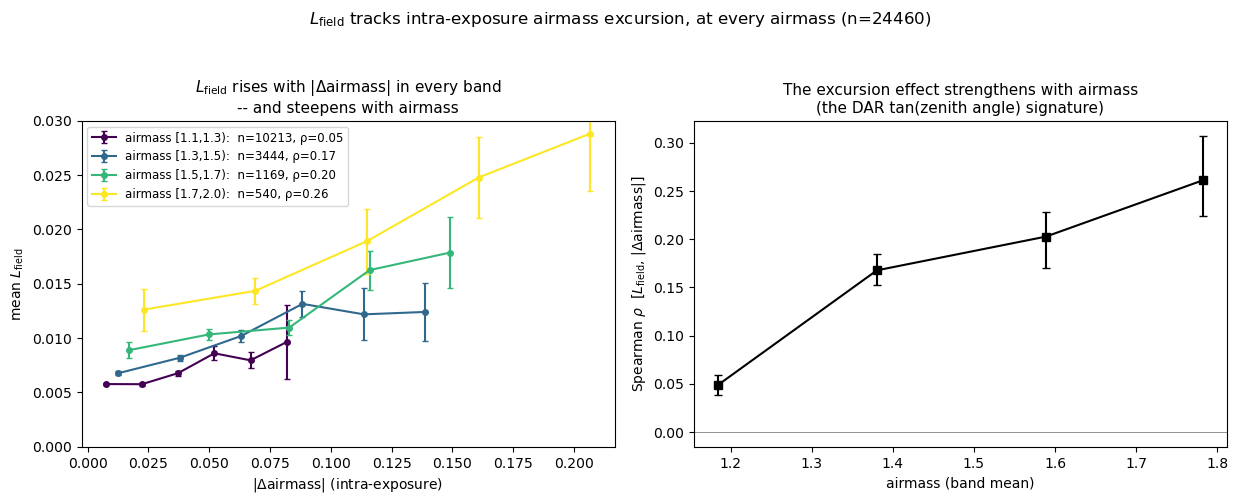

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.8))

am_centers, rhos, rho_los, rho_his = [], [], [], []
for i, (lo, hi) in enumerate(BANDS):
    band = df[(am >= lo) & (am < hi)]
    bx, by, bye = binned_means(band["dam"].to_numpy(), band["L_field"].to_numpy(), nbins=8, min_count=20)
    rho_b, _ = stats.spearmanr(band["dam"], band["L_field"])
    color = plt.cm.viridis(i / (len(BANDS) - 1))
    axL.errorbar(bx, by, yerr=bye, fmt="o-", color=color, capsize=2, ms=4,
                 label=f"airmass [{lo},{hi}):  n={len(band)}, ρ={rho_b:.2f}")

    rho_lo, rho_hi = bootstrap_rho_ci(band["dam"].to_numpy(), band["L_field"].to_numpy())
    am_centers.append(band["airmass"].mean())
    rhos.append(rho_b)
    rho_los.append(rho_b - rho_lo)
    rho_his.append(rho_hi - rho_b)

axL.set_ylim(0, 0.03)
axL.set_xlabel(r"$|\Delta \mathrm{airmass}|$ (intra-exposure)")
axL.set_ylabel(r"mean $L_\mathrm{field}$")
axL.legend(fontsize=8.5, loc="upper left")
axL.set_title(r"$L_\mathrm{field}$ rises with $|\Delta\mathrm{airmass}|$ in every band" "\n-- and steepens with airmass",
              fontsize=11)

axR.errorbar(am_centers, rhos, yerr=[rho_los, rho_his], fmt="s-", color="k", capsize=3, ms=6)
axR.axhline(0, color="gray", lw=0.6)
axR.set_xlabel("airmass (band mean)")
axR.set_ylabel(r"Spearman $\rho$  [$L_\mathrm{field}$, $|\Delta\mathrm{airmass}|$]")
axR.set_title("The excursion effect strengthens with airmass\n(the DAR tan(zenith angle) signature)", fontsize=11)

fig.suptitle(f"$L_\\mathrm{{field}}$ tracks intra-exposure airmass excursion, at every airmass (n={len(df)})",
             y=1.04, fontsize=12)
fig.tight_layout()
plt.show()

**Reading it:** the left panel's curves all slope upward *and* fan out -- the highest-airmass band
(yellow) both starts higher and climbs steeper than the lowest (purple), meaning the same amount of
intra-exposure airmass change costs more light at high airmass than at low airmass. The right panel
makes that explicit: the correlation strength itself climbs from essentially flat near zenith to
clearly positive at high airmass, tracking the $\tan(\text{zenith angle})$ growth DAR predicts. Together
they show this isn't an airmass-level confound -- it's a genuine intra-exposure effect that gets more
important exactly where DAR theory says it should.

## Bonus: what the loss actually looks like across the focal plane

`L_field` itself is a single number per exposure -- the field-*averaged* loss. The quantity it's
averaged from is a full per-fiber loss **map**, generated by the same underlying math
(`telemetry_mining.fiber_loss`) but not currently exposed as its own `Exposure` attribute; this section
reads a precomputed version of that map (`data/dar_gfa_fiber_loss_metric_v2.parquet`) to show what the
spatial pattern behind `L_field` looks like.

The pattern is a **quadrupole** aligned with the zenith direction (elongated one way along the
zenith axis, compressed the perpendicular way) -- but it rotates with the parallactic angle from
exposure to exposure, so simply averaging many exposures' maps in the camera's own fixed frame washes
it out. Rotating (**derotating**) each exposure's map into a common zenith-aligned frame before
averaging aligns the pattern instead of cancelling it. We also subtract the radial (rotation-invariant)
component from each map first, since it's much larger than the quadrupole and would otherwise swamp it
visually.

In [7]:
field = pd.read_parquet(TM_ROOT / "data" / "dar_gfa_fiber_loss_metric_v2.parquet")
field = field[field["airmass"] > 1.6]
print(f"{field['EXPID'].nunique()} exposures, {len(field)} (exposure, grid-point) rows at airmass>1.6")

q = np.deg2rad(field["parallactic"].to_numpy())
c, s = np.cos(q), np.sin(q)
U, V, loss = field["U"].to_numpy(), field["V"].to_numpy(), field["loss"].to_numpy()

# zenith-derotated coordinates: rotate each exposure's grid by its own parallactic angle
up = U * c + V * s
vp = -U * s + V * c

1026 exposures, 25650 (exposure, grid-point) rows at airmass>1.6


In [8]:
from scipy.stats import binned_statistic_2d

# The field only has 6 discrete radii (a Cartesian grid cut to a disk), so binning in polar
# (radius, angle) matches its structure much better than a Cartesian rebin would.
R_EDGES = np.array([0.0, 0.15, 0.35, 0.5, 0.65, 0.75, 0.9])
N_ANGLE_BINS = 16
THETA_EDGES = np.linspace(-np.pi, np.pi, N_ANGLE_BINS + 1)


def polar_stack(u, v, loss):
    r, theta = np.hypot(u, v), np.arctan2(v, u)
    stat, redge, tedge, _ = binned_statistic_2d(r, theta, loss, statistic="mean", bins=[R_EDGES, THETA_EDGES])
    return stat, redge, tedge


def radial_profile(u, v, loss):
    r = np.hypot(u, v)
    idx = np.clip(np.digitize(r, R_EDGES) - 1, 0, len(R_EDGES) - 2)
    return np.array([loss[idx == i].mean() if (idx == i).any() else np.nan for i in range(len(R_EDGES) - 1)])


fixed_stat, redge, tedge = polar_stack(U, V, loss)
rot_stat, _, _ = polar_stack(up, vp, loss)

monopole = radial_profile(U, V, loss)   # rotation-invariant, so it's the same in both frames
fixed_stat = fixed_stat - monopole[:, None]
rot_stat = rot_stat - monopole[:, None]

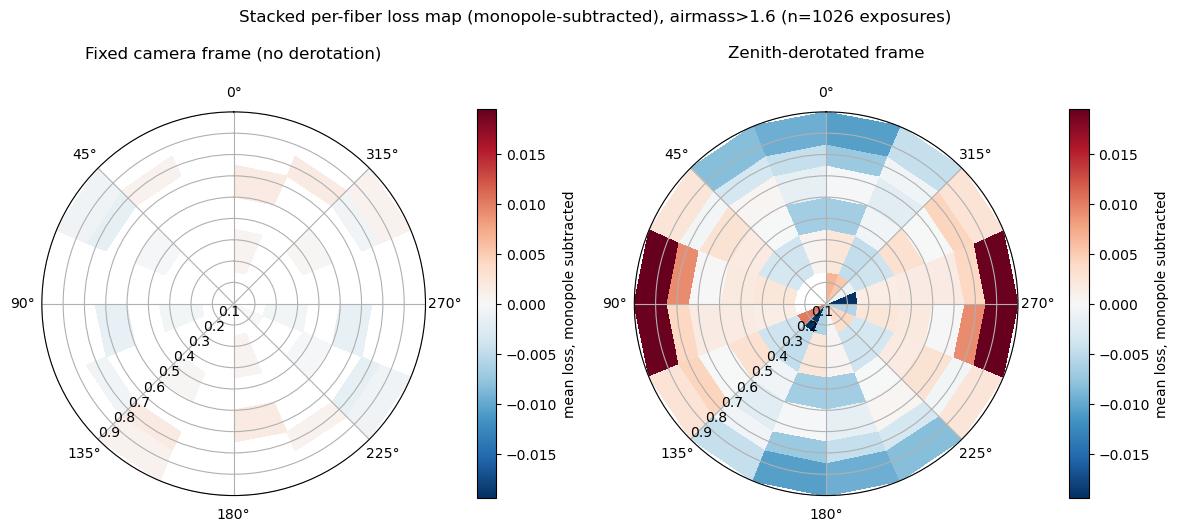

In [9]:
vmax = np.nanmax(np.abs([np.nanpercentile(fixed_stat[np.isfinite(fixed_stat)], [2, 98]),
                          np.nanpercentile(rot_stat[np.isfinite(rot_stat)], [2, 98])]))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), subplot_kw={"projection": "polar"})
Theta, R = np.meshgrid(tedge, redge)
for ax, stat, title in [(axes[0], fixed_stat, "Fixed camera frame (no derotation)"),
                         (axes[1], rot_stat, "Zenith-derotated frame")]:
    im = ax.pcolormesh(Theta, R, stat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="flat")
    ax.set_title(title, pad=20)
    ax.set_theta_zero_location("N")
    ax.set_rlabel_position(135)
    fig.colorbar(im, ax=ax, label="mean loss, monopole subtracted", shrink=0.75, pad=0.1)
fig.suptitle(f"Stacked per-fiber loss map (monopole-subtracted), airmass>1.6 (n={field['EXPID'].nunique()} exposures)")
fig.tight_layout()
plt.show()

The fixed-frame map (left) is faint and structureless -- each exposure's real pattern points in
its own direction, so they cancel on average. The derotated map (right) reveals a clean two-lobed
pattern once every exposure's zenith direction is aligned: this is the DAR quadrupole `L_field` is
summarizing into a single number.

## Summary

- **`Exposure(expid).L_field`** gives an artifact-free, per-exposure DAR/field-distortion loss number,
  computed from the intra-exposure guide-camera drift, with the same NERSC-direct /
  KPNO-lookup-table transparency as `L_see`.
- It's meaningfully more expensive to compute than `L_see` -- cache results to disk for any sample
  worth reusing.
- **`L_field` tracks how much the airmass changes *during* an exposure, not just the airmass level** --
  confirmed by an airmass-controlled analysis, and the effect strengthens with airmass exactly as DAR
  theory predicts. This supports scheduling near transit, and capping exposure length as airmass
  climbs, as concrete levers to reduce this loss.
- The per-fiber map behind `L_field` is a zenith-aligned quadrupole -- visible once exposures are
  derotated into a common frame.

**For more:** `docs/FIBER_LOSS_METRICS.md` (metric definitions), `docs/DAR_FIBER_LOSS_REPORT.md` (the
investigation this metric came out of), and the companion `mirror_seeing_lsee_example.ipynb` notebook
for `L_see`.